# Formação da Imagem — Aula 2

## Objetivo
Explorar como imagens digitais são representadas como estruturas de dados, transformadas por operações pontuais e persistidas em diferentes formatos. Conectar cada experimento a conceitos de ciência da computação: matrizes, tipos, serialização e pipelines.

## Especificações Técnicas
1. Ler imagem em escala de cinza, somar 100 unidades a cada pixel, comparar e gravar
2. Repetir com imagem colorida
3. Processar lote de imagens de um diretório
4. Converter `imagem.csv` (32×32) em PNG

## Base de Dados
- `imagem.csv` — matriz 32×32, valores entre 31 e 226
- Imagens sintéticas geradas neste notebook: gradiente, xadrez colorido, intensidade constante

## Material de Referência
- [OpenCV imread/imwrite](https://docs.opencv.org/4.x/d4/da8/group__imgcodecs.html)
- Próxima aula: `../Aula 3/notebook.ipynb`

## Parte 0: Setup e convenções

1. Setup completo (uma vez, na raiz do repo):

   ```powershell
   .\scripts\setup.ps1
   ```

2. **Em toda sessão**, ativar o ambiente virtual antes de qualquer código:

   ```powershell
   . .\scripts\activate.ps1
   .\scripts\verify-env.ps1
   ```

   Guia: `docs/EXECUTION.md` — **nunca** use o Python global do sistema.

3. No Jupyter/Cursor, selecionar o kernel **PDI (.venv)**.
4. Git hooks (opcional): `npm run hooks:install:win` — ver `docs/GIT_HOOKS.md`.
5. Importar bibliotecas agrupadas por responsabilidade.
6. Definir caminhos com `pathlib.Path`.
7. Criar diretórios `data/synthetic/` e `data/output/`.
8. Declarar constantes do experimento.

**Conexão CS:** `pathlib` abstrai separadores de caminho (`/` vs `\\`) — o mesmo código roda no Windows, Linux e macOS sem concatenação manual de strings.

**Tarefa:**
- Por que usar `pathlib` em vez de strings com `\\` no Windows?
- O que significa separar `data/synthetic/` (fixtures) de `data/output/` (artefatos derivados)?

In [1]:
# Caminhos e I/O
import sys
from pathlib import Path

# Garantir execução no ambiente virtual (.venv)

# Processamento de imagens
import cv2
from PIL import Image

# Arrays e visualização
import numpy as np
import matplotlib.pyplot as plt

# --- Constantes e diretórios ---
DELTA = 100
CSV_SHAPE = (32, 32)

ROOT = Path.cwd()
if not (ROOT / "imagem.csv").exists():
    candidate = ROOT / "experiment" / "Aula 2"
    if (candidate / "imagem.csv").exists():
        ROOT = candidate

CSV_PATH = ROOT / "imagem.csv"
SYNTHETIC_DIR = ROOT / "data" / "synthetic"
OUTPUT_DIR = ROOT / "data" / "output"
BATCH_OUTPUT_DIR = OUTPUT_DIR / "batch"

for directory in (SYNTHETIC_DIR, OUTPUT_DIR, BATCH_OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"[INFO] ROOT: {ROOT}")
print(f"[OK] Diretórios prontos: synthetic, output, batch")

[INFO] ROOT: c:\dev\digital-image-processing\experiment\Aula 2
[OK] Diretórios prontos: synthetic, output, batch


**Respostas:**

- **pathlib vs strings:** `Path` usa o separador correto do SO automaticamente e evita erros de barra dupla ou barra invertida. É composável (`ROOT / "data" / "output"`).

- **synthetic vs output:** `synthetic/` guarda entradas controladas (fixtures de teste); `output/` guarda resultados derivados que podem ser regenerados — princípio de separar fonte imutável de artefato.

## Parte 1: Experimento 4 — CSV para imagem

1. Carregar `imagem.csv` como array NumPy
2. `reshape(32, 32)` — reindexação row-major de stream linear para grade 2D
3. Converter para `uint8` e exibir
4. Gravar PNG com OpenCV e PIL

**Conexão CS:** CSV é serialização em texto; PNG é binário compactado. Os 1024 inteiros são o **modelo de dados** antes de qualquer codec.

```python
pixels = np.loadtxt("imagem.csv", delimiter=",", dtype=np.uint8)
img = pixels.reshape(32, 32)
```

**Tarefa:**
- Qual o `shape` e `dtype` após o reshape?
- Se trocar `reshape(32, 32)` por `reshape(16, 64)`, o que muda?

[INFO] Carregando CSV: c:\dev\digital-image-processing\experiment\Aula 2\imagem.csv
[OK] shape=(32, 32), dtype=uint8, min=31, max=226


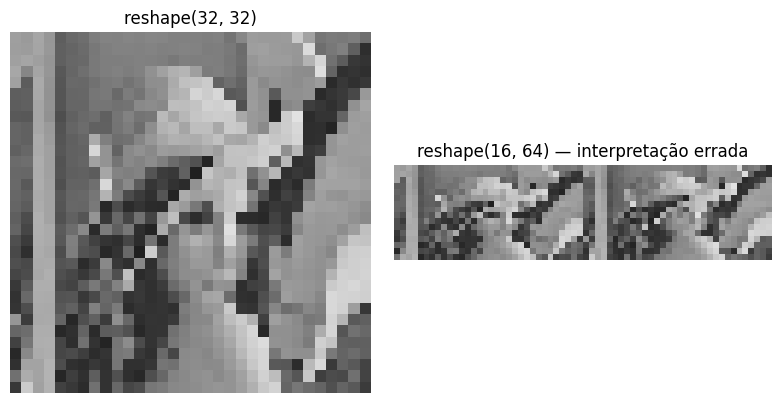

[OK] OpenCV gravou: c:\dev\digital-image-processing\experiment\Aula 2\data\output\imagem_csv_opencv.png
[OK] PIL gravou: c:\dev\digital-image-processing\experiment\Aula 2\data\output\imagem_csv_pil.png


In [2]:
def load_csv_as_image(csv_path: Path, shape: tuple[int, int] = CSV_SHAPE) -> np.ndarray:
    """
    Load a comma-separated grayscale image from CSV into a 2D array.

    Parameters
    ----------
    csv_path : Path
        Path to the CSV file with one row per image row.
    shape : tuple of int
        Target shape ``(height, width)``.

    Returns
    -------
    numpy.ndarray
        Grayscale image with dtype ``uint8`` and shape ``shape``.

    Raises
    ------
    ValueError
        If the number of elements does not match ``shape``.
    """
    print(f"[INFO] Carregando CSV: {csv_path}")
    pixels = np.loadtxt(csv_path, delimiter=",", dtype=np.uint8)
    if pixels.size != shape[0] * shape[1]:
        raise ValueError(f"Esperado {shape[0] * shape[1]} pixels, obtido {pixels.size}")
    img = pixels.reshape(shape)
    print(f"[OK] shape={img.shape}, dtype={img.dtype}, min={img.min()}, max={img.max()}")
    return img


def save_gray_opencv(img: np.ndarray, path: Path) -> None:
    """Save a grayscale image using OpenCV."""
    cv2.imwrite(str(path), img)
    print(f"[OK] OpenCV gravou: {path}")


def save_gray_pil(img: np.ndarray, path: Path) -> None:
    """Save a grayscale image using Pillow (mode L = 8-bit luminance)."""
    Image.fromarray(img, mode="L").save(path)
    print(f"[OK] PIL gravou: {path}")


# Carregar e exibir
img_csv = load_csv_as_image(CSV_PATH)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_csv, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("reshape(32, 32)")
axes[0].axis("off")

img_wrong = img_csv.flatten().reshape(16, 64)
axes[1].imshow(img_wrong, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("reshape(16, 64) — interpretação errada")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# Gravar com ambas as bibliotecas
save_gray_opencv(img_csv, OUTPUT_DIR / "imagem_csv_opencv.png")
save_gray_pil(img_csv, OUTPUT_DIR / "imagem_csv_pil.png")

**Respostas:**

- **shape e dtype:** `(32, 32)` e `uint8`. São 1024 bytes no domínio [0, 255].

- **reshape(16, 64):** Mesmos 1024 valores, mas a **geometria** muda — linhas viram colunas agrupadas diferente. Analogia: reinterpretar um buffer linear com dimensões erradas (como struct layout incorreto).

## Parte 2: Gerar imagens sintéticas

Criar fixtures controladas para prever o resultado da soma +100:

| Arquivo | Conteúdo | Uso |
|---------|----------|-----|
| `gradient_gray.png` | Gradiente 0→255 | Testar saturação em pixels altos |
| `checker_color.png` | Xadrez vermelho/azul | Ver transformação por canal |
| `constant_150.png` | Todos pixels = 150 | Após +100 → 250 (sem clip) |

**Conexão CS:** Fixtures sintéticas isolam comportamento — padrão de engenharia de testes.

**Tarefa:** Por que `constant_150` é útil para validar a soma +100?

[OK] Fixtures salvas em data/synthetic/


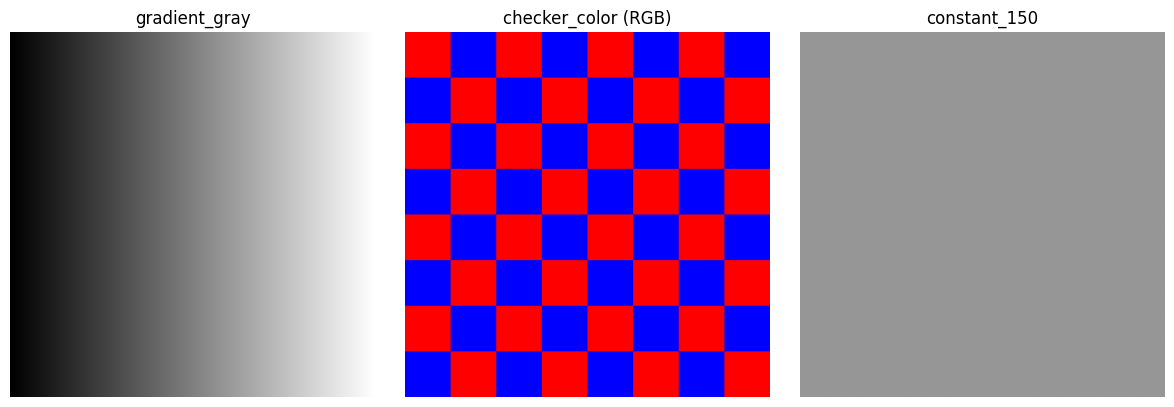

In [3]:
def make_gradient(size: int = 256) -> np.ndarray:
    """
    Create a horizontal grayscale gradient from 0 to 255.

    Parameters
    ----------
    size : int
        Height and width of the square image.

    Returns
    -------
    numpy.ndarray
        Grayscale image with shape ``(size, size)``.
    """
    row = np.linspace(0, 255, size, dtype=np.uint8)
    return np.tile(row, (size, 1))


def make_checkerboard(size: int = 256, square: int = 32) -> np.ndarray:
    """
    Create an RGB checkerboard with red and blue squares.

    Parameters
    ----------
    size : int
        Image height and width.
    square : int
        Side length of each checker square.

    Returns
    -------
    numpy.ndarray
        Color image in RGB order with shape ``(size, size, 3)``.
    """
    img = np.zeros((size, size, 3), dtype=np.uint8)
    red = np.array([255, 0, 0], dtype=np.uint8)
    blue = np.array([0, 0, 255], dtype=np.uint8)
    for i in range(0, size, square):
        for j in range(0, size, square):
            color = red if ((i // square) + (j // square)) % 2 == 0 else blue
            img[i : i + square, j : j + square] = color
    return img


def make_constant(value: int, size: int = 256) -> np.ndarray:
    """
    Create a grayscale image with a single intensity value.

    Parameters
    ----------
    value : int
        Pixel intensity in [0, 255].
    size : int
        Image height and width.

    Returns
    -------
    numpy.ndarray
        Grayscale image filled with ``value``.
    """
    return np.full((size, size), value, dtype=np.uint8)


gradient_gray = make_gradient()
checker_rgb = make_checkerboard()
constant_150 = make_constant(150)

cv2.imwrite(str(SYNTHETIC_DIR / "gradient_gray.png"), gradient_gray)
cv2.imwrite(str(SYNTHETIC_DIR / "checker_color.png"), cv2.cvtColor(checker_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(SYNTHETIC_DIR / "constant_150.png"), constant_150)

print("[OK] Fixtures salvas em data/synthetic/")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gradient_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("gradient_gray")
axes[0].axis("off")
axes[1].imshow(checker_rgb)
axes[1].set_title("checker_color (RGB)")
axes[1].axis("off")
axes[2].imshow(constant_150, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("constant_150")
axes[2].axis("off")
plt.tight_layout()
plt.show()

**Respostas:**

- **constant_150:** Com todos os pixels iguais, o resultado esperado é exatamente 250 — sem ambiguidade de saturação ou wrap. É um **teste unitário visual** da operação +100.

## Parte 3: Experimento 1 — Escala de cinza (+100)

Pipeline: `ler → exibir → somar 100 → comparar → gravar`

Duas implementações intencionais:
1. **Ingênua:** `astype(int) + 100` sem clip — pode causar wrap em `uint8`
2. **Correta:** `cv2.add` ou `np.clip` — saturação em [0, 255]

**Conexão CS:** Soma pontual com tipo finito = aritmética com domínio limitado, não álgebra real.

**Tarefa:** Quantos pixels saturam em 255 no gradiente após +100?

[INFO] OpenCV imread: shape=(256, 256), dtype=uint8
[INFO] PIL convert L: shape=(256, 256), dtype=uint8
[INFO] Pixels saturados em 255: 25856
[INFO] Pixels diferentes (naive vs safe): 25600


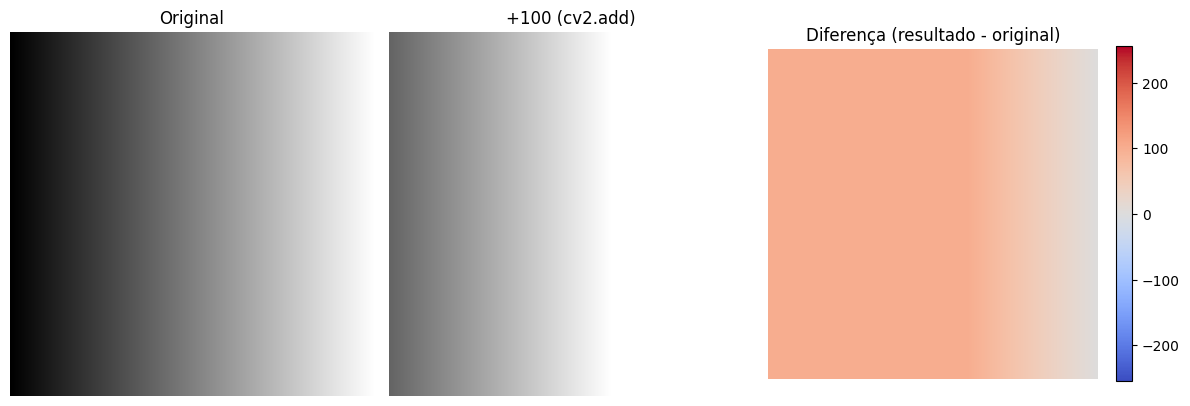

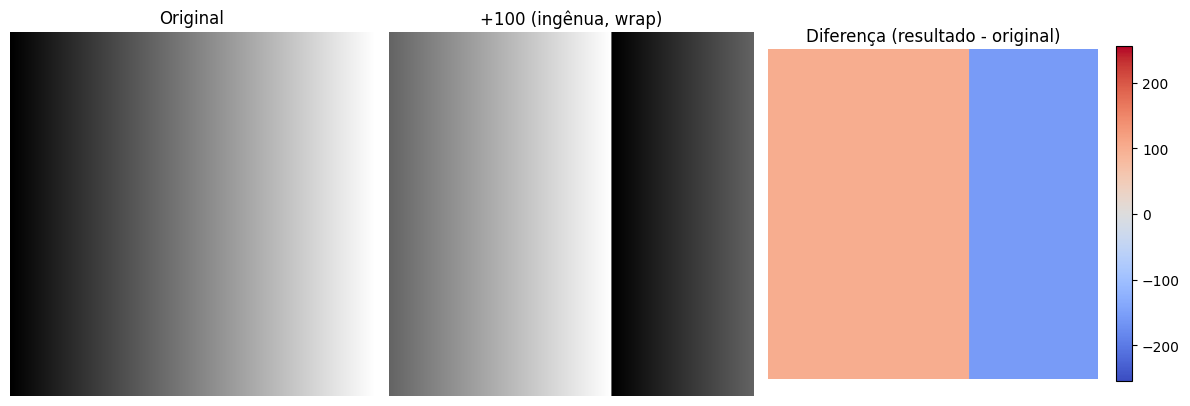

[OK] OpenCV gravou: c:\dev\digital-image-processing\experiment\Aula 2\data\output\gradient_gray_plus100.png
[INFO] constant_150 após +100: único valor = [250]


In [4]:
def brighten_naive(img: np.ndarray, delta: int = DELTA) -> np.ndarray:
    """
    Add delta to each pixel without clipping (may wrap on uint8 cast).

    Parameters
    ----------
    img : numpy.ndarray
        Input grayscale image.
    delta : int
        Value added to each pixel.

    Returns
    -------
    numpy.ndarray
        Image after naive addition cast to uint8.
    """
    return (img.astype(np.int16) + delta).astype(np.uint8)


def brighten(img: np.ndarray, delta: int = DELTA) -> np.ndarray:
    """
    Add delta to each pixel with saturation at [0, 255].

    Parameters
    ----------
    img : numpy.ndarray
        Input image (grayscale or multi-channel).
    delta : int
        Value added to each pixel.

    Returns
    -------
    numpy.ndarray
        Saturated image with same shape as input.
    """
    if img.ndim == 2:
        return cv2.add(img, delta)
    return cv2.add(img, (delta, delta, delta))


def show_gray_comparison(original: np.ndarray, result: np.ndarray, title: str) -> None:
    """Display original, result and per-pixel difference."""
    diff = result.astype(np.int16) - original.astype(np.int16)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(result, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title(title)
    axes[1].axis("off")
    im = axes[2].imshow(diff, cmap="coolwarm", vmin=-255, vmax=255)
    axes[2].set_title("Diferença (resultado - original)")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    plt.tight_layout()
    plt.show()


# OpenCV
path_gray = SYNTHETIC_DIR / "gradient_gray.png"
img_gray_cv = cv2.imread(str(path_gray), cv2.IMREAD_GRAYSCALE)
print(f"[INFO] OpenCV imread: shape={img_gray_cv.shape}, dtype={img_gray_cv.dtype}")

# PIL (comparação)
img_gray_pil = np.array(Image.open(path_gray).convert("L"))
print(f"[INFO] PIL convert L: shape={img_gray_pil.shape}, dtype={img_gray_pil.dtype}")

# Versão ingênua vs correta
result_naive = brighten_naive(img_gray_cv)
result_safe = brighten(img_gray_cv)

saturated = np.sum(result_safe == 255)
wrapped = np.sum(result_naive != result_safe)
print(f"[INFO] Pixels saturados em 255: {saturated}")
print(f"[INFO] Pixels diferentes (naive vs safe): {wrapped}")

show_gray_comparison(img_gray_cv, result_safe, f"+{DELTA} (cv2.add)")

if wrapped > 0:
    show_gray_comparison(img_gray_cv, result_naive, f"+{DELTA} (ingênua, wrap)")

save_gray_opencv(result_safe, OUTPUT_DIR / "gradient_gray_plus100.png")

# Validar constant_150: esperado 250
const_img = cv2.imread(str(SYNTHETIC_DIR / "constant_150.png"), cv2.IMREAD_GRAYSCALE)
const_result = brighten(const_img)
print(f"[INFO] constant_150 após +100: único valor = {np.unique(const_result)}")

**Respostas:**

- **Pixels saturados:** No gradiente horizontal, pixels com valor original > 155 saturam em 255 (pois 155 + 100 = 255). São as colunas da direita da imagem.

- **Wrap ingênuo:** Sem clip, `220 + 100 = 320` vira `64` ao converter para `uint8` (320 mod 256) — comportamento incorreto para PDI.

## Parte 4: Experimento 2 — Imagem colorida (+100)

1. Ler `checker_color.png` com OpenCV (BGR) e PIL (RGB)
2. Aplicar +100 por canal com `cv2.add`
3. Comparar original, resultado e saturação por canal

**Conexão CS:** Imagem RGB = tensor `(H, W, 3)` — cada pixel é um vetor de 3 intensidades.

**Tarefa:** Por que somar no canal B (índice 0 no BGR) afeta o que vemos como vermelho?

[INFO] OpenCV BGR shape: (256, 256, 3)
[INFO] PIL RGB shape: (256, 256, 3)


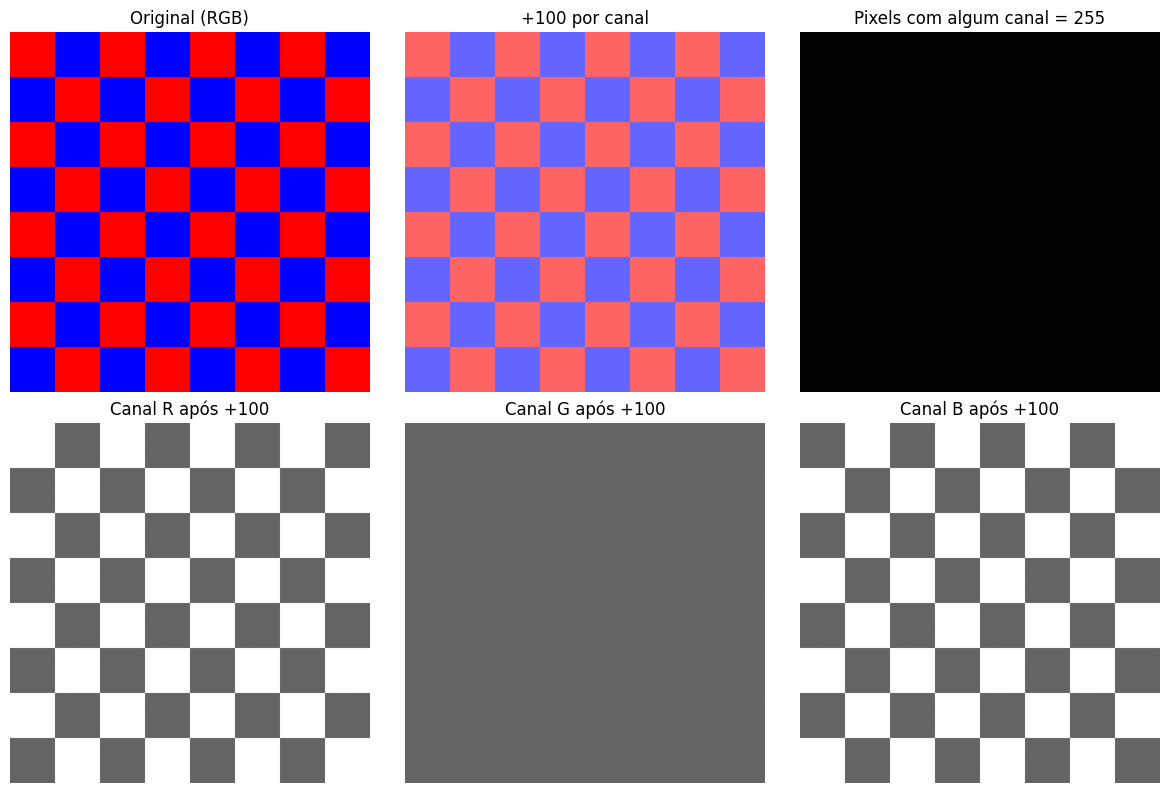

[OK] Gravado: c:\dev\digital-image-processing\experiment\Aula 2\data\output\checker_color_plus100.png


In [5]:
path_color = SYNTHETIC_DIR / "checker_color.png"

# OpenCV lê em BGR
img_bgr = cv2.imread(str(path_color), cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f"[INFO] OpenCV BGR shape: {img_bgr.shape}")

# PIL lê em RGB nativamente
img_pil_rgb = np.array(Image.open(path_color).convert("RGB"))
print(f"[INFO] PIL RGB shape: {img_pil_rgb.shape}")

result_bgr = brighten(img_bgr)
result_rgb = cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB)

# Saturação por canal (em RGB para interpretação humana)
saturation_mask = np.any(result_rgb == 255, axis=2)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original (RGB)")
axes[0, 0].axis("off")
axes[0, 1].imshow(result_rgb)
axes[0, 1].set_title(f"+{DELTA} por canal")
axes[0, 1].axis("off")
axes[0, 2].imshow(saturation_mask, cmap="gray")
axes[0, 2].set_title("Pixels com algum canal = 255")
axes[0, 2].axis("off")

channel_names = ["R", "G", "B"]
for c in range(3):
    axes[1, c].imshow(result_rgb[:, :, c], cmap="gray", vmin=0, vmax=255)
    axes[1, c].set_title(f"Canal {channel_names[c]} após +{DELTA}")
    axes[1, c].axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / "checker_color_plus100.png"), result_bgr)
print(f"[OK] Gravado: {OUTPUT_DIR / 'checker_color_plus100.png'}")

**Respostas:**

- **Canal B em BGR:** OpenCV armazena pixels como `(B, G, R)`. O índice 0 é azul, não vermelho. Ao exibir sem `cvtColor`, o que deveria ser vermelho aparece azulado — ordem de armazenamento ≠ percepção humana (RGB).

## Parte 5: Experimento 3 — Processamento em lote

Aplicar `brighten` a todos os PNG em `data/synthetic/` e gravar em `data/output/batch/`.

**Conexão CS:** Padrão **map** sobre coleção — função pura `f(img) → img'` aplicada a N arquivos.

**Tarefa:** Como detectar automaticamente se a imagem é cinza ou colorida?

In [6]:
def read_image(path: Path) -> np.ndarray | None:
    """
    Read an image from disk, preserving color when present.

    Parameters
    ----------
    path : Path
        Path to the image file.

    Returns
    -------
    numpy.ndarray or None
        Loaded image array, or None if reading failed.
    """
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"[ERRO] Falha ao ler: {path}")
    return img


def is_color(img: np.ndarray) -> bool:
    """Return True if image has 3 color channels."""
    return img.ndim == 3 and img.shape[2] >= 3


def process_batch(input_dir: Path, output_dir: Path, delta: int = DELTA) -> dict:
    """
    Brighten all PNG images in input_dir and save to output_dir.

    Parameters
    ----------
    input_dir : Path
        Directory with source PNG files.
    output_dir : Path
        Directory for output files.
    delta : int
        Brightness increment per pixel.

    Returns
    -------
    dict
        Summary with keys ``processed``, ``errors``, ``files``.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    summary = {"processed": 0, "errors": 0, "files": []}

    for path in sorted(input_dir.glob("*.png")):
        print(f"[INFO] Processando: {path.name}")
        img = read_image(path)
        if img is None:
            summary["errors"] += 1
            continue

        out = brighten(img, delta)
        out_path = output_dir / f"{path.stem}_plus{delta}.png"
        cv2.imwrite(str(out_path), out)
        summary["processed"] += 1
        summary["files"].append(out_path.name)
        kind = "color" if is_color(img) else "gray"
        print(f"[OK] {path.name} ({kind}) -> {out_path.name}")

    return summary


batch_summary = process_batch(SYNTHETIC_DIR, BATCH_OUTPUT_DIR)
print(f"\n[OK] Lote concluído: {batch_summary['processed']} arquivos, {batch_summary['errors']} erros")
print(f"[INFO] Arquivos gerados: {batch_summary['files']}")

[INFO] Processando: checker_color.png
[OK] checker_color.png (color) -> checker_color_plus100.png
[INFO] Processando: constant_150.png
[OK] constant_150.png (gray) -> constant_150_plus100.png
[INFO] Processando: gradient_gray.png
[OK] gradient_gray.png (gray) -> gradient_gray_plus100.png

[OK] Lote concluído: 3 arquivos, 0 erros
[INFO] Arquivos gerados: ['checker_color_plus100.png', 'constant_150_plus100.png', 'gradient_gray_plus100.png']


**Respostas:**

- **Detectar cinza vs colorida:** `img.ndim == 2` → escala de cinza; `img.ndim == 3 and img.shape[2] == 3` → colorida. `cv2.IMREAD_UNCHANGED` preserva canais originais.

## Parte 6: Síntese e ponte para Aula 3

Resumo do que aprendemos:

| Camada CS | Conceito | Neste notebook |
|-----------|----------|----------------|
| Modelo de dados | Matriz 2D / tensor 3D | CSV, gradient, checker |
| Tipo | `uint8` em [0, 255] | Soma com saturação vs wrap |
| Serialização | CSV (texto) vs PNG (binário) | Parte 1 e gravações |
| Operação pontual | f(p) = p + 100 | Partes 3–5 |
| Pipeline | ler → transformar → gravar | Todo o fluxo |

**Próximo passo (Aula 3):** A soma +100 **desloca** o histograma de intensidades — veremos isso formalmente no notebook da Aula 3.

**Checklist — aprendi de verdade?**
1. Qual `shape`/`dtype` de cinza vs RGB?
2. O que acontece com pixel 220 após +100 sem clip?
3. Por que `reshape` no CSV importa?
4. Diferença `cv2.imread` vs `Image.open`?
5. Como generalizar para N arquivos?

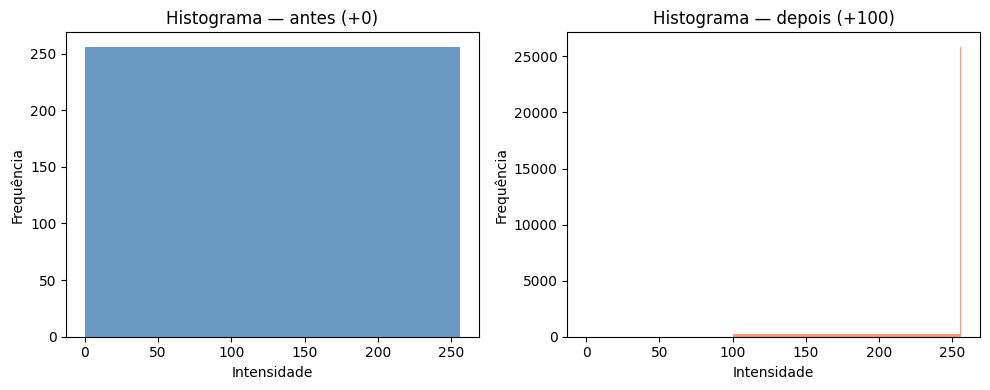

[INFO] O pico do histograma deslocou ~100 unidades para a direita (até saturar em 255).


In [7]:
# Histograma opcional — antecipa Aula 3
before = cv2.imread(str(SYNTHETIC_DIR / "gradient_gray.png"), cv2.IMREAD_GRAYSCALE)
after = brighten(before)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(before.ravel(), bins=256, range=(0, 256), color="steelblue", alpha=0.8)
axes[0].set_title("Histograma — antes (+0)")
axes[0].set_xlabel("Intensidade")
axes[0].set_ylabel("Frequência")

axes[1].hist(after.ravel(), bins=256, range=(0, 256), color="coral", alpha=0.8)
axes[1].set_title(f"Histograma — depois (+{DELTA})")
axes[1].set_xlabel("Intensidade")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

print("[INFO] O pico do histograma deslocou ~100 unidades para a direita (até saturar em 255).")

**Respostas — Checklist final:**

1. **Cinza:** `(H, W)`, `uint8`. **RGB:** `(H, W, 3)`, `uint8`.
2. **220 + 100 sem clip:** Em `uint8` puro, vira `64` (wrap modular 256). Com `cv2.add`, vira `255` (saturação).
3. **reshape:** Define a geometria 2D; valores iguais com shape errado = imagem distorcida.
4. **cv2 vs PIL:** OpenCV retorna `ndarray` em BGR; PIL retorna objeto `Image` em RGB — modos e ordem de canais diferem.
5. **N arquivos:** Função pura `brighten` + `glob` + loop — mesmo pipeline, entradas diferentes (map).